<a href="https://colab.research.google.com/github/vg137/ibd-causal-multiomics/blob/main/01_gwas_to_genes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# For accessing the dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


In [3]:
# file locations and names
data_dir = "/content/drive/MyDrive/ibd_data"
gwas_data_subdir = "gwas/raw"
gwas_filename = "GCST90473841.h.tsv.gz"
gwas_file_path = f"{data_dir}/{gwas_data_subdir}/{gwas_filename}"

Since we will be streaming data from the compressed GWAS file frequently, we define a simple function to construct an iterator over the chunks of the file.

In [4]:
def get_gwas_iterator(chunksize=10**6, columns=None):
    """Returns a new iterator over the compressed GWAS file"""

    gwas_chunk_iterator = pd.read_csv(gwas_file_path,
                                        sep="\t", # standard GWAS files use TAB separated values
                                        compression="gzip", # standard GWAS files use gzip compression
                                        chunksize=chunksize,
                                        usecols=columns
                                      )

    return gwas_chunk_iterator

### Generating a Parquet file

For faster manipulation of the GWAS data, we will convert it to a better suited format called [parquet](https://en.wikipedia.org/wiki/Apache_Parquet)

In [5]:
import pyarrow as pa
import pyarrow.parquet as pq

parquet_data_subdir = "gwas/parquet"
parquet_filename = "GCST90473841.parquet"
parquet_file_path = f"{data_dir}/{parquet_data_subdir}/{parquet_filename}"

Uncomment the following block, if the parquet file has not been generated yet or is not available

In [6]:
# writer = None

# for chunk in get_gwas_iterator():
#     table = pa.Table.from_pandas(chunk, preserve_index=False)

#     if writer is None:
#         writer = pq.ParquetWriter(parquet_file_path,
#                                     table.schema,
#                                     compression="zstd",
#                                  )

#     writer.write_table(table)

# if writer is not None:
#     writer.close()

### Quality control

#### Basic info and sanity checks

In [11]:
pq.read_metadata(parquet_file_path) # metadata like number of rows and columns

  created_by: parquet-cpp-arrow version 18.1.0
  num_columns: 18
  num_rows: 84399074
  num_row_groups: 85
  format_version: 2.6
  serialized_size: 172025

Total rows = 84,399,074 $\implies$ These many different SNPs were studied

In [12]:
pq.read_schema(parquet_file_path).names # all the columns in the gwas summary statistics

['chromosome',
 'base_pair_location',
 'effect_allele',
 'other_allele',
 'beta',
 'standard_error',
 'effect_allele_frequency',
 'p_value',
 'rsid',
 'ID',
 'INFO',
 'n',
 'TEST',
 'CHISQ',
 'EXTRA',
 'hm_coordinate_conversion',
 'hm_code',
 'variant_id']

In [17]:
pq.read_table(parquet_file_path, columns=["chromosome"]).to_pandas()["chromosome"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22])

From the above output, we learn that all 22 pairs of autosomal chromosomes are studied but not the X/Y chromosomes

#### Missing values

In [22]:
important_columns = ["chromosome", "base_pair_location", "p_value"]

for col in important_columns:
    print(col, pd.read_parquet(parquet_file_path, columns=[col])[col].isna().sum())

chromosome 0
base_pair_location 0
p_value 0


Above output shows that none of the important parameters are missing

#### p-value histogram

In [23]:
pvalues = pd.read_parquet(parquet_file_path, columns=["p_value"])["p_value"]

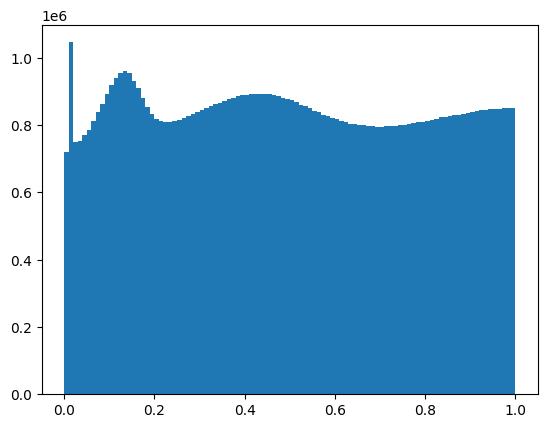

In [27]:
plt.hist(pvalues, bins=100)
plt.show()

The p-values are distributed almost uniformly apart from a sharp spike around 0. This means that a substantial number of SNPs have below the genome-wide significance threshold of $5 \times 10^{-8}$, indicating strong signals.

#### Manhattan plot